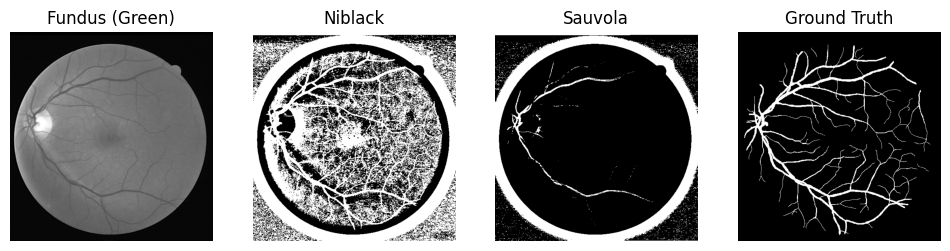

Average Sensitivity (Niblack): 0.8705930576985692
Average Sensitivity (Sauvola): 0.219193444799643


In [3]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage.io import imread

from skimage.filters import threshold_niblack, threshold_sauvola

# Paths (Kaggle DRIVE dataset)
img_dir = r"C:\Github\assignment-3\data\DRIVE\training\images"
gt_dir  = r"C:\Github\assignment-3\data\DRIVE\training\1st_manual"

# Sensitivity function
def sensitivity(pred, gt):
    tp = np.sum((pred == 1) & (gt == 1))
    fn = np.sum((pred == 0) & (gt == 1))
    return tp / (tp + fn + 1e-8)

sens_niblack = []
sens_sauvola = []

# Flag for single visualization
vis_done = False

for fname in sorted(os.listdir(img_dir)):
    if not fname.endswith(".tif"):
        continue
    
    img_path = os.path.join(img_dir, fname)
    gt_path  = os.path.join(gt_dir, fname.replace("_training.tif", "_manual1.gif"))
    
    # Load image and GT
    img = imread(img_path)
    gt = imread(gt_path)
    gt = np.squeeze(gt) > 0   # FIX: handle (1, H, W) shape
    
    # Green channel
    green = img[:, :, 1]
    green = cv2.normalize(green, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Niblack - detect dark pixels (vessels) using <=
    th_niblack = threshold_niblack(green, window_size=51, k=-0.2)
    pred_niblack = green <= th_niblack
    
    # Sauvola - detect dark pixels (vessels) using <=
    th_sauvola = threshold_sauvola(green, window_size=51, k=0.2)
    pred_sauvola = green <= th_sauvola
    
    # Sensitivity
    sens_niblack.append(sensitivity(pred_niblack, gt))
    sens_sauvola.append(sensitivity(pred_sauvola, gt))
    
    # Visualize only first image
    if not vis_done:
        plt.figure(figsize=(12,4))
        
        plt.subplot(1,4,1)
        plt.imshow(green, cmap='gray')
        plt.title("Fundus (Green)")
        plt.axis('off')
        
        plt.subplot(1,4,2)
        plt.imshow(pred_niblack, cmap='gray')
        plt.title("Niblack")
        plt.axis('off')
        
        plt.subplot(1,4,3)
        plt.imshow(pred_sauvola, cmap='gray')
        plt.title("Sauvola")
        plt.axis('off')
        
        plt.subplot(1,4,4)
        plt.imshow(gt, cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')
        
        plt.show()
        vis_done = True

print("Average Sensitivity (Niblack):", np.mean(sens_niblack))
print("Average Sensitivity (Sauvola):", np.mean(sens_sauvola))
